In [37]:
pip install pandas


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [38]:
import pandas as pd

In [39]:
pip install numpy


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [40]:
import numpy as np

In [41]:
pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [42]:
import seaborn as sns

In [43]:
import matplotlib.pyplot as plt

In [44]:
df = pd.read_csv("/Users/aashishmewada/Desktop/PRISM AI/PRISM-AI/data/raw/customer.csv")

In [45]:
df.head()

,CustomerID,Age,Income,Membership,Tenure,TotalSpend,TotalTransactions,AvgOrderValue,PurchaseFrequency
0,CUST000001,56,44487,Bronze,6.2,1947.40,26,74.90,4.2
1,CUST000002,69,53129,Free,5.4,508.27,7,72.61,1.3
2,CUST000003,46,79368,Free,6.2,1480.80,15,98.72,2.4
3,CUST000004,32,211810,Platinum,3.0,25823.36,64,403.49,21.3
4,CUST000005,60,38682,Free,5.4,452.40,8,56.55,1.5


In [46]:
df.shape

(50000, 9)

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         50000 non-null  str    
 1   Age                50000 non-null  int64  
 2   Income             50000 non-null  int64  
 3   Membership         50000 non-null  str    
 4   Tenure             50000 non-null  float64
 5   TotalSpend         50000 non-null  float64
 6   TotalTransactions  50000 non-null  int64  
 7   AvgOrderValue      50000 non-null  float64
 8   PurchaseFrequency  50000 non-null  float64
dtypes: float64(4), int64(3), str(2)
memory usage: 3.4 MB


In [48]:
df.isnull().sum()

CustomerID           0
Age                  0
Income               0
Membership           0
Tenure               0
TotalSpend           0
TotalTransactions    0
AvgOrderValue        0
PurchaseFrequency    0
dtype: int64

In [49]:
df.duplicated().sum()

np.int64(0)

In [51]:
membership_map = {"free":0 , "Bronze":1, "Silver":2, "Gold":3, "Platinum":4 }
df["Membership"] = df["Membership"].map(membership_map)

In [52]:
df.head()

,CustomerID,Age,Income,Membership,Tenure,TotalSpend,TotalTransactions,AvgOrderValue,PurchaseFrequency
0,CUST000001,56,44487,NaN,6.2,1947.40,26,74.90,4.2
1,CUST000002,69,53129,NaN,5.4,508.27,7,72.61,1.3
2,CUST000003,46,79368,NaN,6.2,1480.80,15,98.72,2.4
3,CUST000004,32,211810,NaN,3.0,25823.36,64,403.49,21.3
4,CUST000005,60,38682,NaN,5.4,452.40,8,56.55,1.5


In [53]:
df = df.drop("CustomerID", axis=1)

In [55]:
df.columns

Index(['Age', 'Income', 'Membership', 'Tenure', 'TotalSpend',
       'TotalTransactions', 'AvgOrderValue', 'PurchaseFrequency'],
      dtype='str')

In [58]:
!pip install scikit-learn

  Using cached scikit_learn-1.9.0-cp314-cp314-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached scipy-1.18.0-cp314-cp314-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.24.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.9.0-cp314-cp314-macosx_12_0_arm64.whl (8.2 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached narwhals-2.24.0-py3-none-any.whl (461 kB)
Using cached scipy-1.18.0-cp314-cp314-macosx_14_0_arm64.whl (20.4 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [68]:
X = df[['Age', 'Income']]

y = df['PurchaseFrequency']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


In [70]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [71]:
from sklearn.cluster import KMeans


kmeans = KMeans(n_clusters=4,random_state=42 )
clusters = kmeans.fit_predict(X_scaled)

In [72]:
df["Customer_Segment"] = clusters

df.head()

,Age,Income,Membership,Tenure,TotalSpend,TotalTransactions,AvgOrderValue,PurchaseFrequency,Customer_Segment
0,56,44487,NaN,6.2,1947.40,26,74.90,4.2,2
1,69,53129,NaN,5.4,508.27,7,72.61,1.3,2
2,46,79368,NaN,6.2,1480.80,15,98.72,2.4,3
3,32,211810,NaN,3.0,25823.36,64,403.49,21.3,0
4,60,38682,NaN,5.4,452.40,8,56.55,1.5,2


In [73]:
import joblib


joblib.dump(
    scaler,
    "../models/segmentation_scaler.pkl"
)

['../models/segmentation_scaler.pkl']

In [74]:
from sklearn.cluster import KMeans


wcss=[]


for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

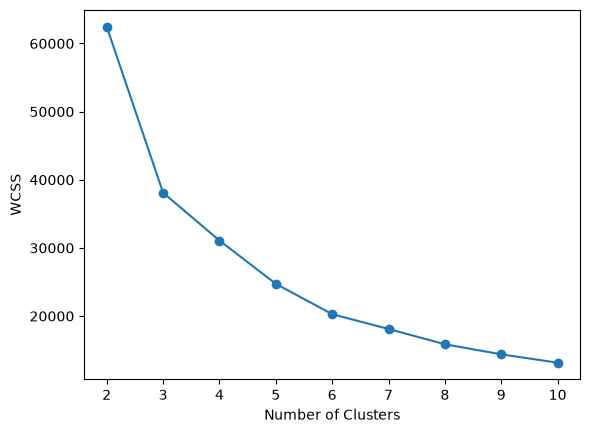

In [75]:
import matplotlib.pyplot as plt


plt.plot(
    range(2,11),
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [77]:
df["Segment"] = clusters

In [78]:
df["Segment"].value_counts()

Segment
1    20338
2    14736
3    10050
0     4876
Name: count, dtype: int64

In [79]:
segment_profile = df.groupby(
    "Segment"
).mean(numeric_only=True)


segment_profile

,Age,Income,Membership,Tenure,TotalSpend,TotalTransactions,AvgOrderValue,PurchaseFrequency,Customer_Segment
Segment,,,,,,,,,
0,39.856850,129590.245283,NaN,3.298441,12375.794215,54.683142,196.608033,16.596924,0.0
1,31.223227,55079.379093,NaN,3.312322,1188.550616,14.067411,72.344940,4.356367,1.0
2,60.223331,43664.261061,NaN,3.312262,720.220759,10.824783,62.664879,3.350658,2.0
3,60.599701,82790.139403,NaN,3.324726,3032.780475,24.693930,102.180529,7.495831,3.0


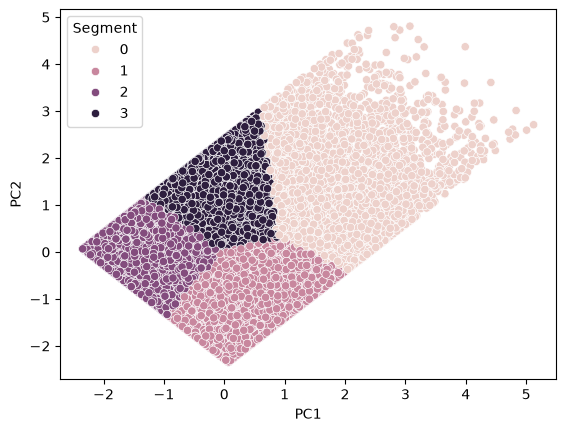

In [80]:
from sklearn.decomposition import PCA
import seaborn as sns


pca = PCA(
    n_components=2
)


X_pca = pca.fit_transform(
    X_scaled
)


plot_df = pd.DataFrame(
    {
        "PC1":X_pca[:,0],
        "PC2":X_pca[:,1],
        "Segment":clusters
    }
)


sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="Segment"
)

plt.show()

In [81]:
joblib.dump(
    kmeans,
    "../models/customer_segmentation.pkl"
)

['../models/customer_segmentation.pkl']

In [84]:
df.to_csv(
    "../data/processed/customer_segments.csv",
    index=False
)

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    X_scaled,
    clusters
)

print("Silhouette Score:", score)